# Sequence Logos

When studying multiple sequence alignments (MSAs), we often want to summarize patterns across many sequences rather than display each one individually. **Sequence logos** offer a compact visual representation: each position in the alignment is shown as a stack of letters, where the total height of the stack reflects how conserved that position is, and the height of each individual letter reflects how often that character appears.

Sequence logos were introduced by Schneider and Stephens {cite}`schneider1990sequence` and have since become a standard tool in bioinformatics for visualizing regulatory motifs, binding sites, and any other position-specific pattern in biological sequences.

## Information Content

The height of each column in a sequence logo is a quantitative measure called **information content**, derived from information theory.

### Shannon Entropy

For position $i$ in the alignment, the **Shannon entropy** measures the uncertainty in the character distribution:

$$H_i = -\sum_{a} f_{i,a} \log_2 f_{i,a}$$

where $f_{i,a}$ is the observed frequency of character $a$ at position $i$. Entropy is zero when every sequence has the same character (complete conservation) and is maximal when all characters appear with equal frequency (maximum uncertainty).

### Information Content in Bits

The **information content** at position $i$ is the reduction in uncertainty relative to the maximum possible entropy:

$$I_i = \log_2(N) - H_i$$

where $N$ is the alphabet size. This gives the following upper limits:

| Alphabet | Size $N$ | Maximum $I_{\max}$ |
|---|---|---|
| DNA / RNA | 4 | $\log_2(4) = 2.00$ bits |
| Amino acids | 20 | $\log_2(20) \approx 4.32$ bits |

A fully conserved position contributes 2 bits (DNA) or ≈4.32 bits (protein); a completely random position contributes 0 bits. Within each column, the height of an individual letter for character $a$ is $I_i \times f_{i,a}$, so more frequent characters occupy a larger fraction of the column.

The higher maximum for amino acid logos reflects the larger alphabet: a conserved protein position carries more than twice the information of a conserved nucleotide position.

## Examples

We use the `logomaker` package {cite}`tareen2020logomaker` to generate sequence logos in Python.

In [1]:
import logomaker
import matplotlib.pyplot as plt

### The Kozak Consensus Sequence

The **Kozak sequence** is a short conserved motif surrounding the AUG start codon in eukaryotic mRNAs, recognised by the ribosome during translation initiation. Described by Marilyn Kozak {cite}`kozak1987analysis`, the consensus is often written (GCC)**R**CCAUGG, where R is a purine (A or G).

Two positions have the strongest effect on translation efficiency:
- **Position −3** (three nucleotides before the A of AUG): a purine is strongly preferred, present in over 80 % of vertebrate mRNAs.
- **Position +4** (the nucleotide immediately after the AUG codon): G is preferred in about 74 % of vertebrate transcripts.

The following 20 sequences show representative Kozak contexts from vertebrate mRNAs, spanning six nucleotides upstream to four nucleotides downstream of the AUG.

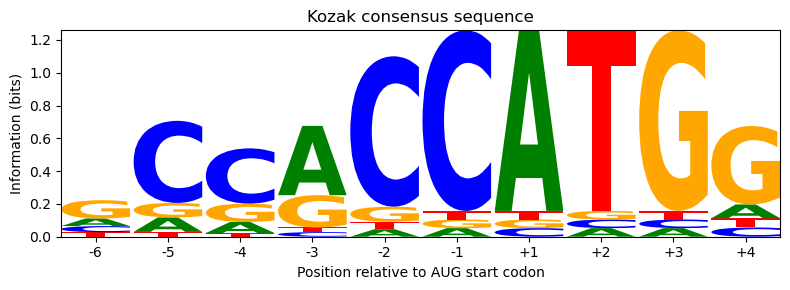

In [2]:
kozak_seqs = [
    "GCCACCATGG",  # canonical Kozak (A at -3, G at +4)
    "GCCGCCATGG",  # G at -3
    "ACCACCATGG",
    "CCCACCATGG",
    "TCCACCATGG",
    "GCAACCATGG",
    "GCGACCATGG",
    "GGCGCCATGG",  # G at -3
    "GCGGCCATGG",  # G at -3
    "AAGACCATGG",
    "CGCGCCATGG",  # G at -3
    "AACACCATGG",
    "CCGACCATGG",
    "ACCGCCATGG",  # G at -3
    "GCCACCATGA",  # A at +4 (weaker context)
    "GCCACCATGC",  # C at +4 (weaker context)
    "GCCACCATGT",  # T at +4 (weaker context)
    "GCAACCATGA",
    "TCCGCCATGG",  # G at -3
    "GCCAGCATGG",
]

kozak_matrix = logomaker.alignment_to_matrix(kozak_seqs, to_type='information')

fig, ax = plt.subplots(figsize=(8, 3))
logomaker.Logo(kozak_matrix, ax=ax, color_scheme='classic')
ax.set_xticks(range(10))
ax.set_xticklabels(['-6', '-5', '-4', '-3', '-2', '-1', '+1', '+2', '+3', '+4'])
ax.set_xlabel('Position relative to AUG start codon')
ax.set_ylabel('Information (bits)')
ax.set_title('Kozak consensus sequence')
plt.tight_layout()
plt.show()

The logo clearly shows the nearly invariant **AUG** at positions +1/+2/+3, the strong **purine** preference at −3, the **G** preference at +4, and relatively little conservation at the remaining positions — exactly what a biotech researcher considers when designing an expression construct.

### PKA Phosphorylation Site

Protein kinase A (PKA) phosphorylates serine or threonine residues in target proteins. The kinase recognises a characteristic sequence motif: two basic residues (almost always Arg, occasionally Lys) appear two and three positions upstream of the phospho-Ser/Thr, giving the consensus **R−R−x−S/T** {cite}`songyang1994use`.

The following sequences show 7 residues centred on the phosphorylatable residue at position 0, drawn from experimentally validated PKA substrates.

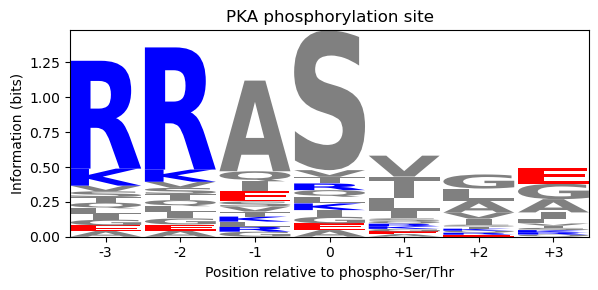

In [3]:
pka_seqs = [
    "RRASLGA",  # Kemptide-like
    "RRASVAI",
    "RRASTLG",  # Thr at P0
    "RRESVAE",  # Glu at P-1
    "RRASLGE",
    "KRASLGA",  # Lys at P-3
    "RRQSTVG",  # Gln at P-1, Thr at P0
    "RRASTIA",  # Thr at P0
    "RRASVIG",
    "RRISVAI",  # Ile at P-1
    "KRASTLG",  # Lys at P-3, Thr at P0
    "RRASILA",
    "RRASTVE",  # Thr at P0
    "RRASVAG",
    "RRASLGE",
    "RRASTLA",  # Thr at P0
    "RRASIGE",
    "RRASVGE",
    "RKASTLG",  # Lys at P-2, Thr at P0
    "RRASVAL",
]

pka_matrix = logomaker.alignment_to_matrix(pka_seqs, to_type='information')

fig, ax = plt.subplots(figsize=(6, 3))
logomaker.Logo(pka_matrix, ax=ax, color_scheme='charge')
ax.set_xticks(range(7))
ax.set_xticklabels(['-3', '-2', '-1', '0', '+1', '+2', '+3'])
ax.set_xlabel('Position relative to phospho-Ser/Thr')
ax.set_ylabel('Information (bits)')
ax.set_title('PKA phosphorylation site')
plt.tight_layout()
plt.show()

The logo highlights the strongly conserved **Arg–Arg** doublet at positions −3 and −2 (tall blue letters — positive charge), the phospho-**S/T** at position 0 where both options are visible, and the largely variable positions elsewhere.

/tmp/ipykernel_2106903/39490927.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


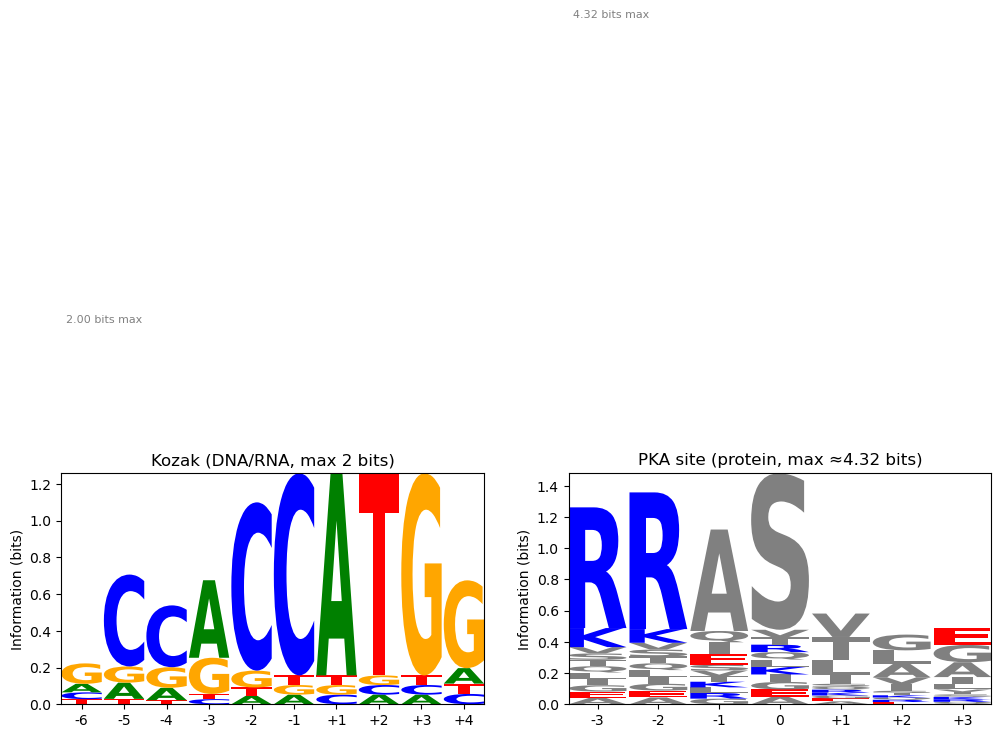

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Kozak logo with DNA maximum marked
logomaker.Logo(kozak_matrix, ax=axes[0], color_scheme='classic')
axes[0].axhline(2.0, color='grey', linestyle='--', linewidth=0.8)
axes[0].text(0.01, 2.08, '2.00 bits max', transform=axes[0].get_yaxis_transform(),
             fontsize=8, color='grey')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(['-6', '-5', '-4', '-3', '-2', '-1', '+1', '+2', '+3', '+4'])
axes[0].set_ylabel('Information (bits)')
axes[0].set_title('Kozak (DNA/RNA, max 2 bits)')

# PKA logo with protein maximum marked
logomaker.Logo(pka_matrix, ax=axes[1], color_scheme='charge')
axes[1].axhline(4.32, color='grey', linestyle='--', linewidth=0.8)
axes[1].text(0.01, 4.40, '4.32 bits max', transform=axes[1].get_yaxis_transform(),
             fontsize=8, color='grey')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['-3', '-2', '-1', '0', '+1', '+2', '+3'])
axes[1].set_ylabel('Information (bits)')
axes[1].set_title('PKA site (protein, max ≈4.32 bits)')

plt.tight_layout()
plt.show()

Comparing the two logos, note how the conserved R–R in the PKA site approaches its alphabet maximum (≈4.32 bits) while the most conserved nucleotide positions in the Kozak sequence are bounded by 2 bits. The dashed lines make these theoretical ceilings explicit.

```{bibliography}
:filter: docname in docnames
```